#Background

What constitutes good music? The question is answerable in two ways, the first way it's answered is by musicians, the group of people who make the music. A survey would yield intrisic answers like pitch, key, tune, harmonious, stages etc. This mystical quest would involve great minds in history, many of which are no longer living.

The second way the question being answered, even though in a less profound way, is through listeners of music. Assuming the people who listen to music makes up the market for music, this study is an attempt to answer this quesiton by market's predictive power.

Commercially speaking, the music production companies relies on understanding trends and predicting which songs will become popular. For example, potify, as a major music streaming platform, offers detailed data on songs, such as acoustic features, popularity scores, and listener activity. This project uses that data to predict whether a song could reach the top 10. These predictions can help artists, record labels, and streaming platforms decide which songs to focus on promoting. It also demonstrates how machine learning can connect data analysis with the creative aspects of humanity.

##Problem Statement

Our project will attempt addressing the problem with limited-scope focus on 21th century popular music in the United Sates of America, utilizing entertainment industry data recorded through Internet-based music consumption platform, while the bigger question will only be addressed in subsequent studies.

The ability to predict whether a song will become a top 10 hit is a challenge in the music industry due to the dynamic and subjective nature of listener preferences. With vast amounts of song data available, it is difficult for artists, record labels, and streaming platforms to identify which songs have the potential to become highly successful. By using machine learning models to analyze song features, such as tempo, energy, and popularity metrics, this project seeks to address this challenge and provide a data-driven approach to predicting a song's likelihood of success.





##Stakeholders

Some of the key stakeholders in this project include **songwriters and producers**, who create the content and benefit from understanding what makes a song popular. Access to data-driven insights can help them refine their creative process and increase the likelihood of success.

Another important group of stakeholders is **investors** and executives in record companies. These individuals allocate resources to fund artists and projects, aiming to produce popular music that generates high returns. Predictive models can guide their decisions and optimize investments.

**Commercial streaming platforms**, such as Spotify and Apple Music, are also key stakeholders. They can use this data to improve playlist curation and recommend songs likely to engage users, enhancing listener experience and retention.

Finally, it's vitally to important to note who should be **prohibited** from using our prediction machine: public-interested platforms in the braodest sense, which means platforms that are not privately owned in capital or spirit. That is because this model specifically caters to the taste of a segment of music listeners that are taste-drive, trend-driven, and herd-mentalitized. **Public universities, music college programs, governmental platforms, and music societies** shall be strictly prohibited from using this model to discriminate against less time-popular music, as such actions will evitably affect the cultivation and preservation of the whole spectrum of music diversity by mankind as a collective.

This approach could also be valuable to music marketers, advertisers, industry researchers and even psychology researchers, all of whom can use these insights to better align their strategies with current and emerging trends, or gain deeper insights of the psychological dispostion of the public.

##Business Criticality

Predicting whether a song will reach the top 10 is a high-impact application in the music industry, directly influencing revenue generation and competitive positioning. For record labels, accurate predictions can optimize marketing budgets by focusing resources on songs with the highest potential, reducing the risk of promoting less successful tracks. Streaming platforms benefit by increasing user engagement and retention through better-curated playlists, which in turn boosts subscription rates and advertising revenue.

Additionally, songwriters and producers gain insights that improve their ability to create commercially viable music, ensuring a steady stream of marketable content. Investors and stakeholders in the industry also stand to benefit, as data-driven decision-making minimizes financial risks and maximizes return on investment.

For the broader music ecosystem, this project enhances the ability to anticipate trends, making the industry more agile and adaptive. By leveraging machine learning to bridge creativity with analytics, it provides stakeholders a competitive edge in a fast-paced and ever-changing market.

##Other Considerations

We will discuss plans to project our work in this small-scope experiment to bigger issues in discussion section.

#Data

##Data Description

**Dataset has been take from Kaggle and modified: https://www.kaggle.com/datasets/alyssaackerman/bais2800-group-data?select=Most_Streamed_Songs.csv**

**Dataset Details of Spotify Most Streamed Songs:**

Basic Track Information:

* track_name: Name of the song.
* artist(s)_name: Name of the artist(s) performing the song.
* artist_count: Number of artists contributing to the song.
* released_year, released_month, released_day: Release date details.

Streaming Metrics:

* in_spotify_playlists: Number of Spotify playlists the song is featured in.
* in_spotify_charts: Rank of the song on Spotify charts.
* streams: Total number of streams on Spotify.
* in_apple_playlists, in_apple_charts: Presence in Apple Music playlists and charts.
* in_deezer_playlists, in_deezer_charts: Presence in Deezer playlists and charts.
* in_shazam_charts: Rank on Shazam charts.

Musical Attributes:

* bpm: Beats per minute, representing the tempo of the song.
* key: Key of the song.
* mode: Indicates whether the song is in a major or minor mode.
* danceability_%: Suitability of the song for dancing.
* valence_%: Positivity of the song’s musical content.
* energy_%: Perceived energy level of the song.
* acousticness_%: Acoustic sound presence in the song.
* instrumentalness_%: Proportion of instrumental content in the track.
* liveness_%: Presence of live performance elements.
* speechiness_%: Amount of spoken words in the song.

**Spotify Top 10000 Streamed Songs:**

* Position - Spotify Ranking
* Artist Name - Artist Name
* Song Name - Song Name
* Days - No of days since the release of the song (Updated)
* Top 10 (xTimes) - No of times inside top 10
* Peak Position - Peak position attained
* Peak Position (xTimes) - No of times Peak position attained
* Peak Streams - Total no of streams during Peak position

##Data Considerations

In the initial dataset we only have a list of songs with their attributes.  To predict if the song will be top 10 in the Spotify charts, we needed to combine a list of songs with the top 10 attribute from Spotify (given a recent year) and compare that to another list of songs with more detailed song attributes and then merge the list together giving us a top_10_x_times target variable and independant variables suchs as liveness, speech, dancability, valence, etc. for this analysis.

See:

https://www.kaggle.com/datasets/abdulszz/spotify-most-streamed-songs

https://www.kaggle.com/datasets/rakkesharv/spotify-top-10000-streamed-songs



```
# Exmaple code to format dataset on local machine
# Match song title and artist from 2 files and combine

import pandas as pd

# Read the CSV files
streamed = pd.read_csv('Most_Streamed_Songs.csv')
top = pd.read_csv('Top_1000_Songs.csv')

# Initialize an empty list to store the combined results
songs = []

# Iterate through each row in the 'top' dataframe
for index, t_row in top.iterrows():
    # Find the matching rows in the 'streamed' dataframe
    s_rows = streamed[streamed['track_name'].str.contains(t_row['Song Name'], na=False)]

    for s_index, s_row in s_rows.iterrows():
        # Check if the artist names match (loosely) after removing spaces
        if s_row['artists_name'].replace(' ', '').lower() in t_row['Artist Name'].replace(' ', '').lower():
            print(s_row)
            print(t_row)

            # Combine the two rows into a single dictionary
            combined_obj = {**t_row.to_dict(), **s_row.to_dict()}
            songs.append(combined_obj)
        else:
            print("No Match")
            print(s_row)
            print(t_row)

# Convert the results to a DataFrame if needed
combined_df = pd.DataFrame(songs)

# Optionally, save the combined results to a new CSV file
combined_df.to_csv('songs_data_v1.csv', index=False)

```






##Exploratory Data Analysis (EDA)

In [ ]:
# Import necessary libraries
from google.colab import files
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Open file dialog to upload CSV file
uploaded = files.upload()

import pandas as pd

# Load data
songs_data = pd.read_csv(list(uploaded.keys())[0])

Saving songs_data_v1.csv to songs_data_v1.csv


**Top 10 Songs By Appearance in the Top 10 List:**

In [ ]:

# Analyzing songs with the most frequent top-10 appearances
top_10_appearances = songs_data.sort_values(by='top_10_x_times', ascending=False)

# Selecting the top 10 songs with the most top-10 appearances
top_10_frequent = top_10_appearances[['artist_name', 'song_name', 'top_10_x_times']].head(10)

# Display the top 10 songs with the most top-10 appearances
print(top_10_frequent)


         artist_name                        song_name  top_10_x_times
0     Glass Animals                        Heat Waves             248
1        The Weeknd                   Blinding Lights             233
2      Harry Styles                         As It Was             203
3        The Weeknd                         The Hills             194
4             Drake                         One Dance             187
5    Olivia Rodrigo                          good 4 u             187
6        Juice WRLD                      Lucid Dreams             178
7       Post Malone                           Circles             163
8      Mariah Carey   All I Want for Christmas Is You             162
9  The Chainsmokers                            Closer             158


**Top Song Features in the Top 10 List:**

In [ ]:
# Selecting key audio features for the top songs
features = ['danceability_%', 'energy_%', 'valence_%',
            'acousticness_%', 'instrumentalness_%',
            'liveness_%', 'speechiness_%']

# Filtering the top 10 songs
top_songs_features = top_10_appearances.head(10)[features]

# Calculating the mean feature values for the top songs
feature_means = top_songs_features.mean()

# Displaying the feature contributions
feature_means


,0
danceability_%,57.0
energy_%,63.0
valence_%,45.1
acousticness_%,23.5
instrumentalness_%,0.0
liveness_%,17.0
speechiness_%,8.8


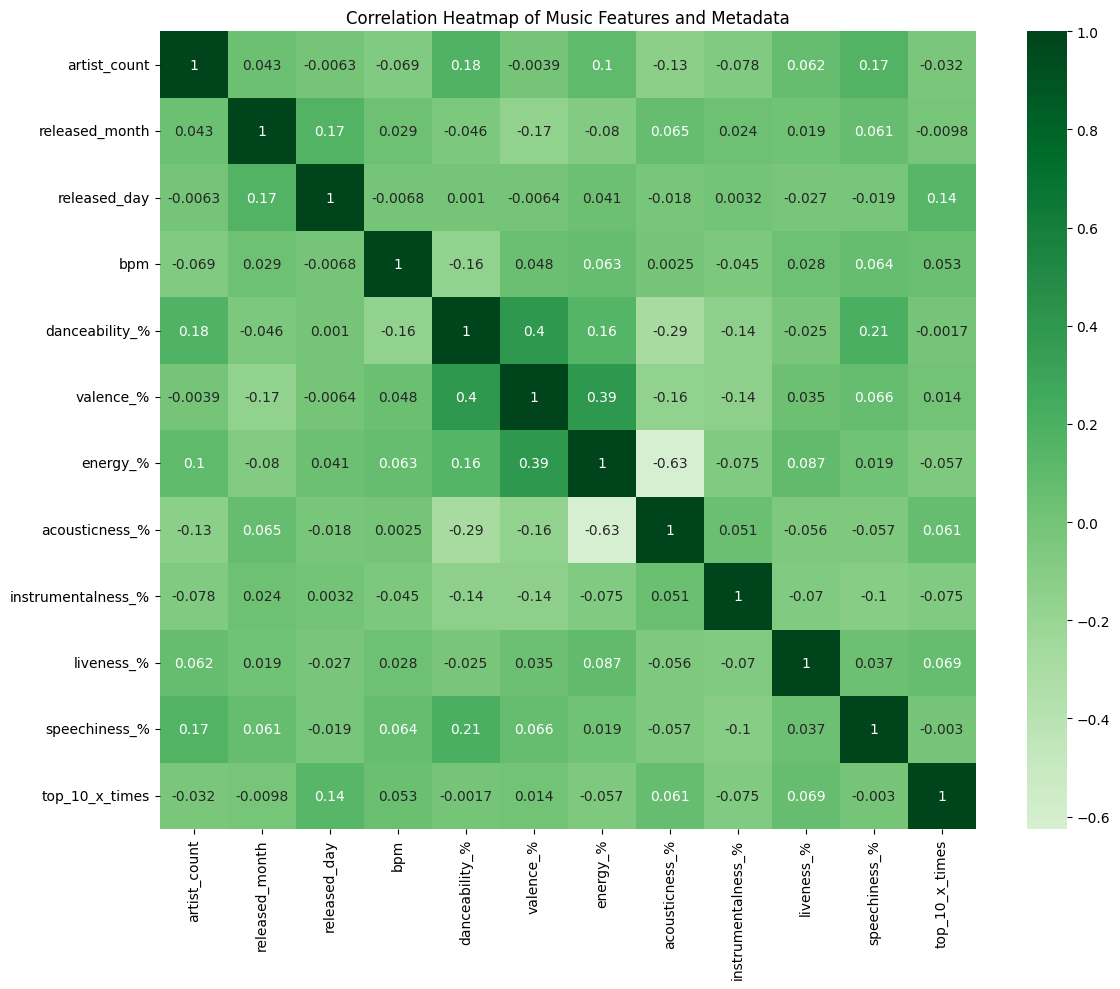

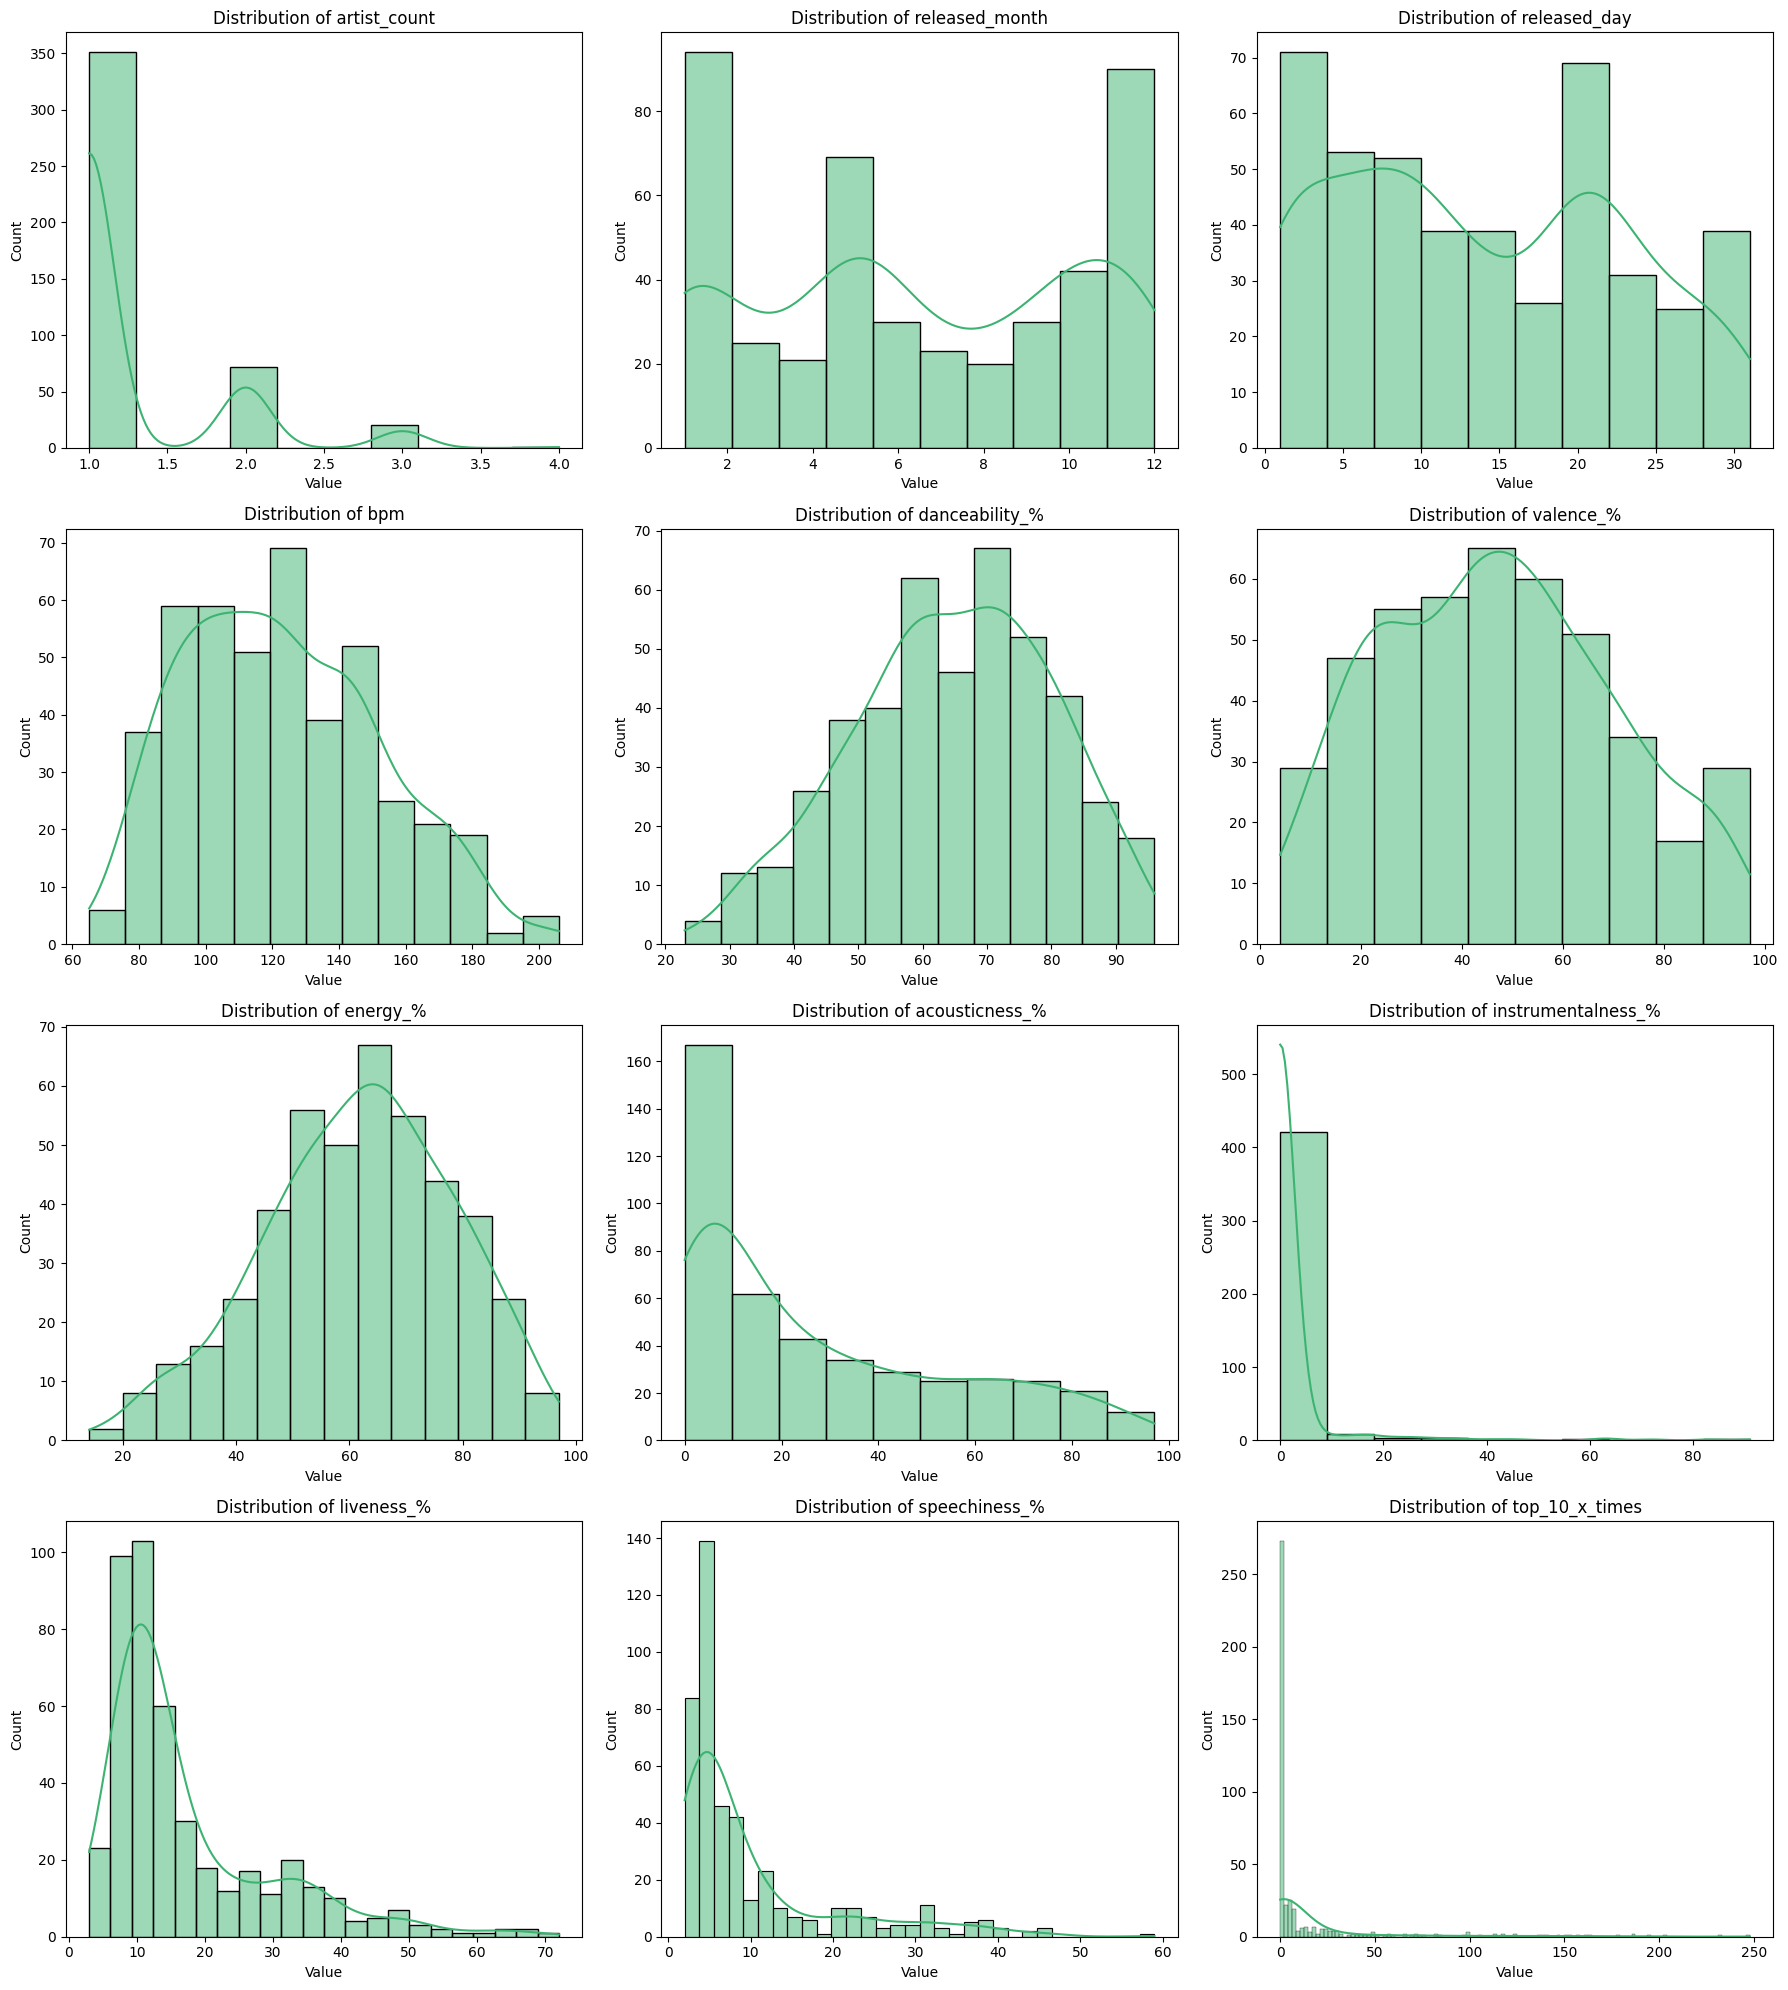

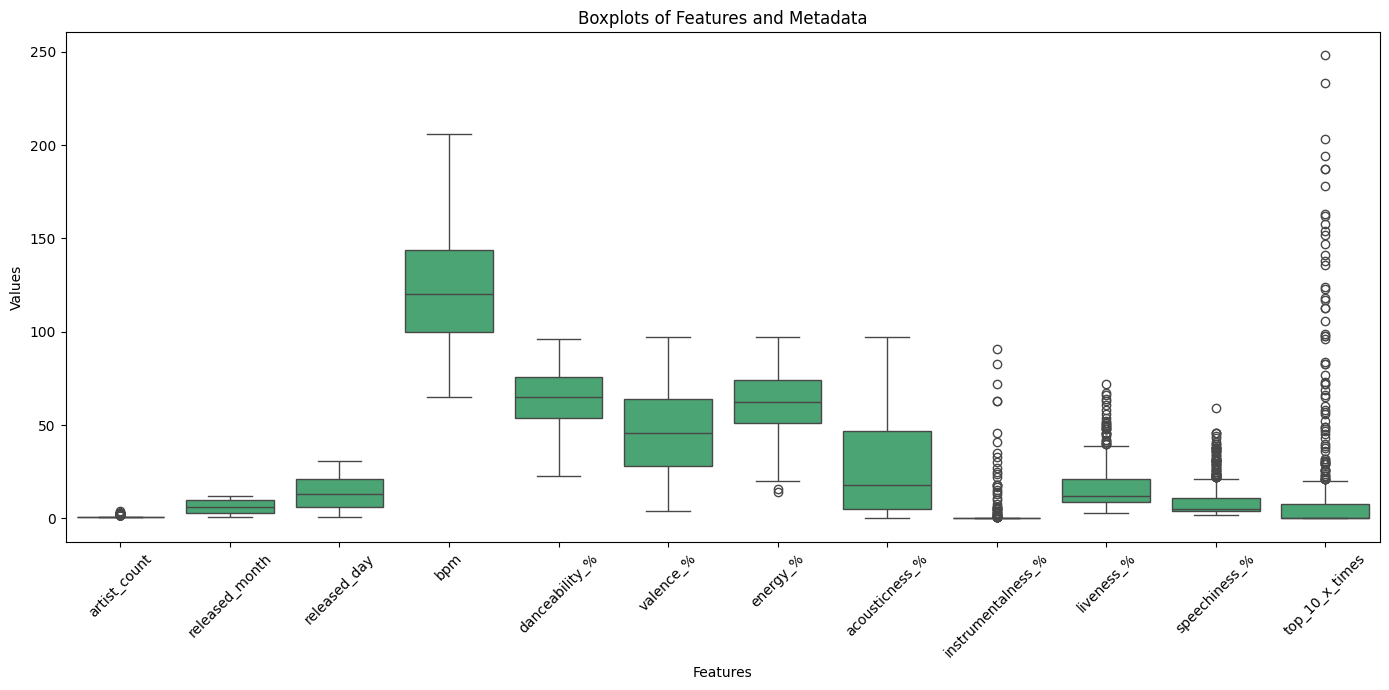

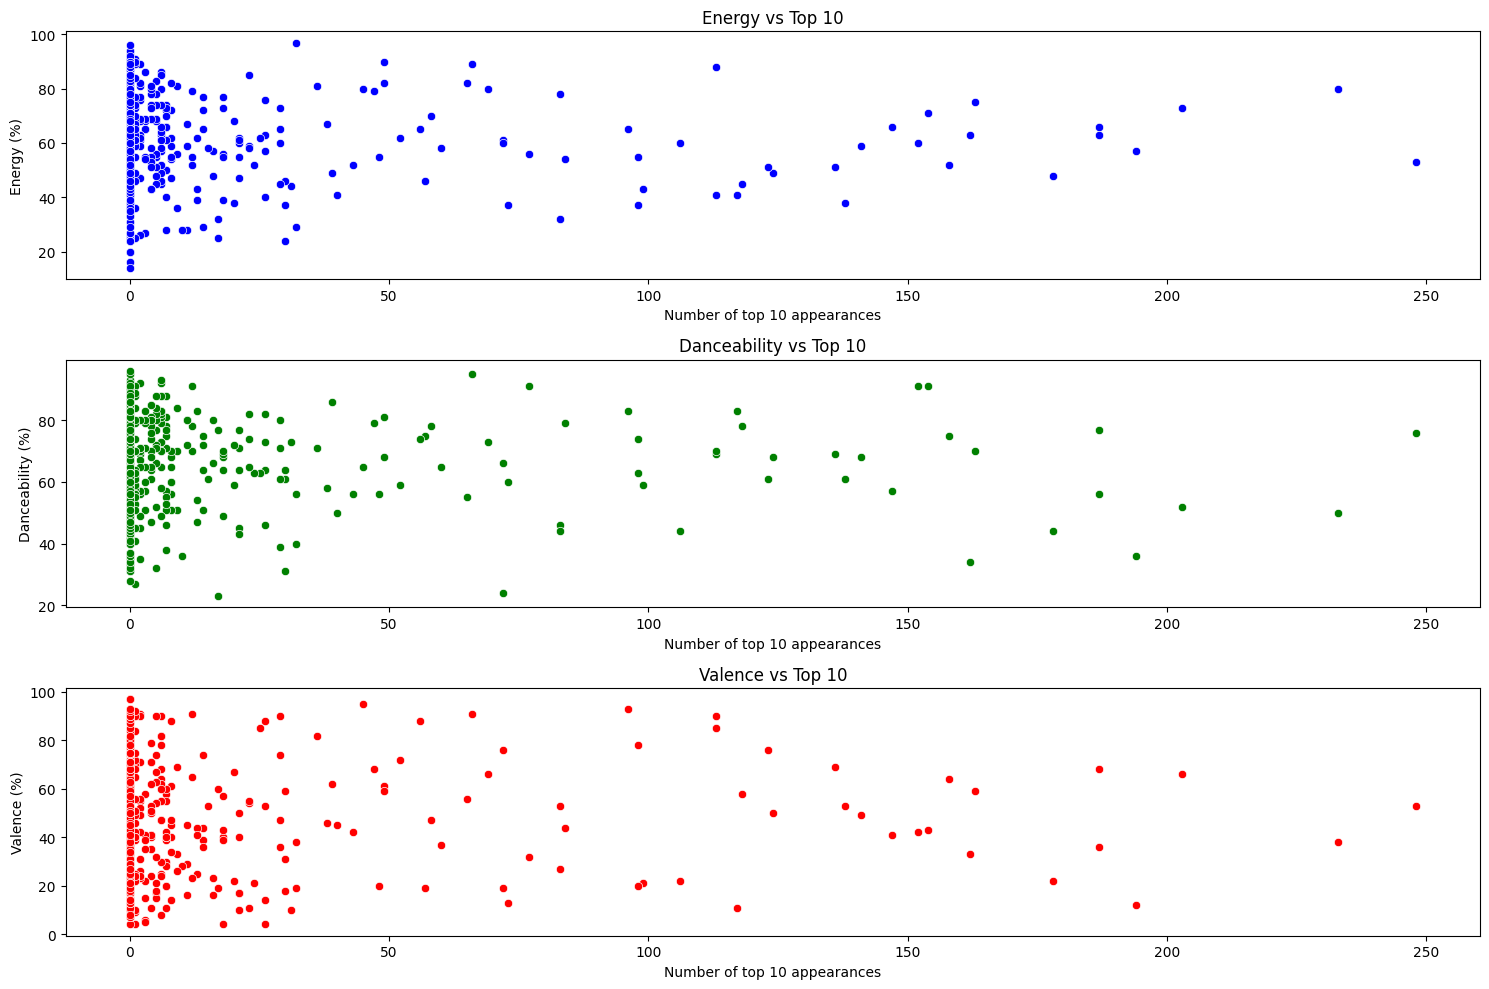

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean the dataset
df = pd.read_csv('songs_data_v1.csv')

# Specify the columns to analyze, including the newly added features
feature_columns = [
    'artist_count', 'released_month', 'released_day', 'bpm',
    'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
    'instrumentalness_%', 'liveness_%', 'speechiness_%', 'top_10_x_times'
]

# Convert percentage columns to numeric, removing % symbol if present
pct_columns = [
    'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
    'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

for col in pct_columns:
    # Convert to string first, then remove % and convert to numeric
    df[col] = pd.to_numeric(df[col].astype(str).str.rstrip('%'), errors='coerce')

# Drop any rows with missing values in the specified feature columns
df = df.dropna(subset=feature_columns)

# Create a figure for the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[feature_columns].corr(), annot=True, cmap='Greens', center=0)
plt.title('Correlation Heatmap of Music Features and Metadata')
plt.tight_layout()
plt.show()

# Create histograms for each feature
num_features = len(feature_columns)
rows = (num_features + 2) // 3  # Calculate number of rows for the grid
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
axes = axes.ravel()

for idx, col in enumerate(feature_columns):
    sns.histplot(data=df, x=col, ax=axes[idx], kde=True, color='mediumseagreen')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Count')

# Remove empty plots if any
for i in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Create boxplots
plt.figure(figsize=(14, 7))
df_melted = df[feature_columns].melt()
sns.boxplot(x='variable', y='value', data=df_melted, color='mediumseagreen')
plt.xticks(rotation=45)
plt.title('Boxplots of Features and Metadata')
plt.xlabel('Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

# Scatter plots for Energy, Danceability, and Valence against the top_10_x_times target
plt.figure(figsize=(15, 10))

# Scatter plot for Energy vs Top 10
plt.subplot(3, 1, 1)
sns.scatterplot(data=df, x='top_10_x_times', y='energy_%', color='blue')
plt.title('Energy vs Top 10')
plt.xlabel('Number of top 10 appearances')
plt.ylabel('Energy (%)')

# Scatter plot for Danceability vs Top 10
plt.subplot(3, 1, 2)
sns.scatterplot(data=df, x='top_10_x_times', y='danceability_%', color='green')
plt.title('Danceability vs Top 10')
plt.xlabel('Number of top 10 appearances')
plt.ylabel('Danceability (%)')

# Scatter plot for Valence vs Top 10
plt.subplot(3, 1, 3)
sns.scatterplot(data=df, x='top_10_x_times', y='valence_%', color='red')
plt.title('Valence vs Top 10')
plt.xlabel('Number of top 10 appearances')
plt.ylabel('Valence (%)')

plt.tight_layout()
plt.show()

# If date column exists, create trend analysis
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    plt.figure(figsize=(14, 7))

    for col in feature_columns:
        if col not in ['artist_count', 'released_month', 'released_day']:  # Trend analysis for continuous features only
            daily_avg = df.groupby('date')[col].mean()
            plt.plot(daily_avg.index, daily_avg.values, label=col)

    plt.title('Trend Analysis of Features Over Time')
    plt.xlabel('Date')
    plt.ylabel('Average Values')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


**Visualize the Features and Their Relationship to Top Songs:**

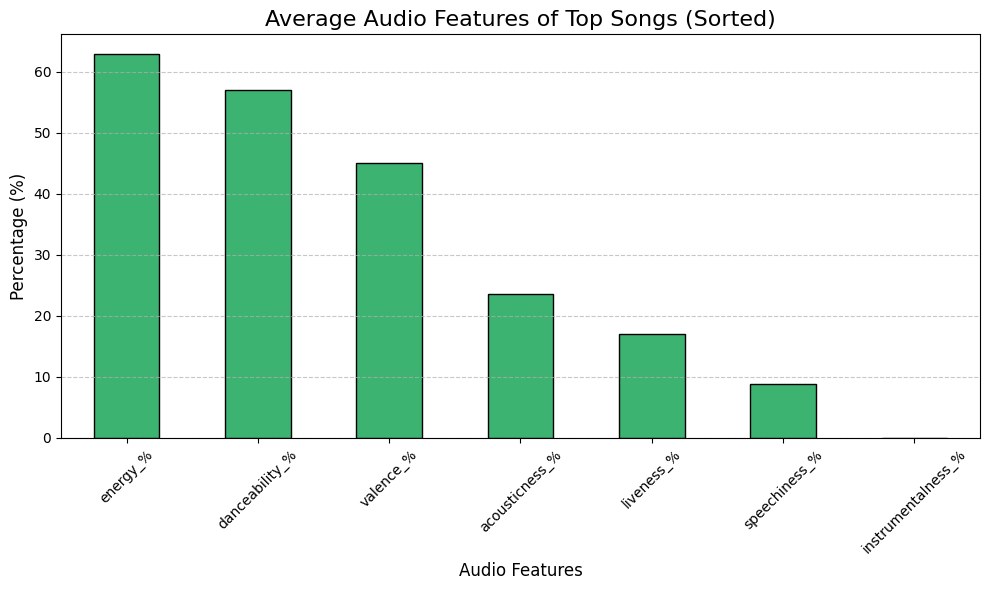

In [ ]:
# Sorting the feature means in descending order for visualization
sorted_features = feature_means.sort_values(ascending=False)

# Visualizing the sorted mean feature values for the top songs
plt.figure(figsize=(10, 6))
sorted_features.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title("Average Audio Features of Top Songs (Sorted)", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Audio Features", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Compare This to Some Songs on the Bottom of the List:**

          artist_name                                 song_name  \
228      Beach House                                 Space Song   
310  Sebastian Yatra                              Dos Oruguitas   
309     Taylor Swift                              The Great War   
308           Miguel                                 Sure Thing   
307      Oliver Tree                                   Miss You   
306             Joji                                Die For You   
305   Arctic Monkeys   Why'd You Only Call Me When You're High?   
304        Sam Smith                       I'm Not The Only One   
303           ACRAZE                                Do It To It   
302         Coldplay                                     Sparks   

     top_10_x_times  
228               0  
310               0  
309               0  
308               0  
307               0  
306               0  
305               0  
304               0  
303               0  
302               0  


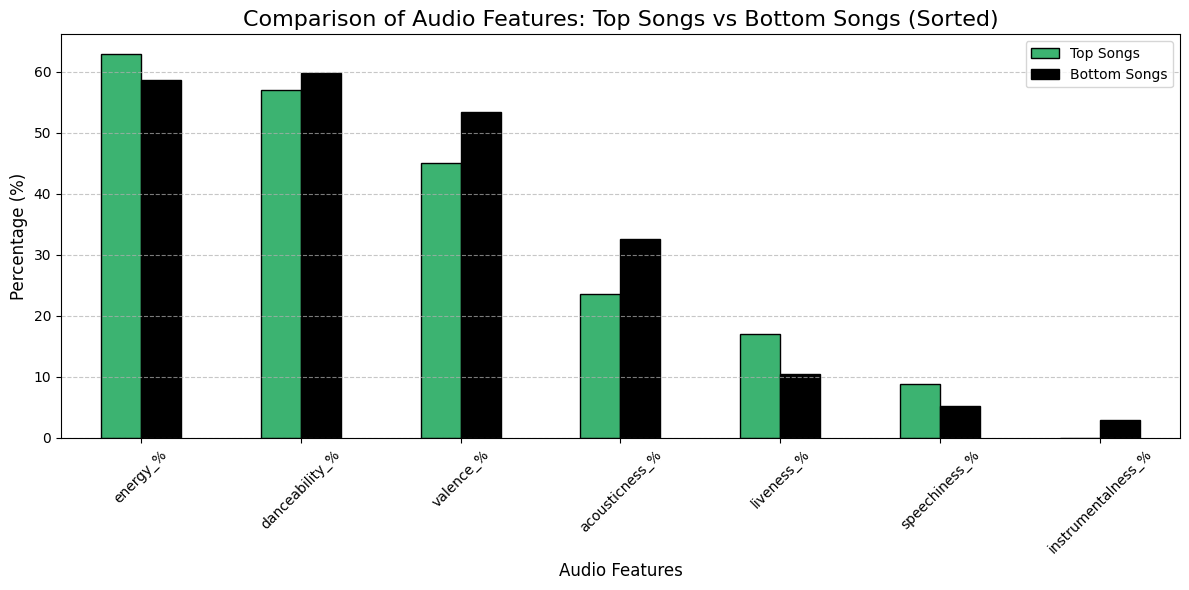

In [ ]:
# Extracting the bottom 10 songs based on their top-10 appearances
bottom_10_songs = songs_data.sort_values(by='top_10_x_times', ascending=True).head(10)

# Calculating the mean feature values for the bottom songs
bottom_songs_features = bottom_10_songs[features].mean()

# Print bottom songs
print(bottom_10_songs[['artist_name', 'song_name', 'top_10_x_times']])

# Creating a comparison between top and bottom songs
feature_comparison = pd.DataFrame({
    'Top Songs': feature_means,
    'Bottom Songs': bottom_songs_features
})

# Sorting the features by the top songs' values in descending order
sorted_feature_comparison = feature_comparison.sort_values(by='Top Songs', ascending=False)

# Visualizing the sorted comparison
sorted_feature_comparison.plot(kind='bar', figsize=(12, 6), color=['mediumseagreen','black'], edgecolor='black')
plt.title("Comparison of Audio Features: Top Songs vs Bottom Songs (Sorted)", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Audio Features", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Models

##With Simple Features

###Split Train and Test Data -Simple###

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Step 1: Define Features and Target
features = ['danceability_%', 'energy_%', 'valence_%',
            'acousticness_%', 'instrumentalness_%',
            'liveness_%', 'speechiness_%']
target = (songs_data['top_10_x_times'] > 0).astype(int)  # Binary classification target

X = songs_data[features]
y = target

# Step 2: Handle Missing Values
X = X.fillna(X.mean())

# Step 3: Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

###Model 1 - Random Forest Classifier with Simple Features

In [ ]:


# Step 5: Train the Random Forest Model
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Step 6: Evaluate the Model
y_pred = model.predict(X_test)

# Display evaluation metrics
classification_report_result = classification_report(y_test, y_pred)
confusion_matrix_result = confusion_matrix(y_test, y_pred)

# Step 7: Feature Importance
feature_importances = model.feature_importances_

# Display the evaluation results and feature importance to the user
import pandas as pd
results = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)



Feature Importance Table:
              Feature  Importance
0      danceability_%    0.177337
5          liveness_%    0.169169
2           valence_%    0.160121
3      acousticness_%    0.156905
1            energy_%    0.155851
6       speechiness_%    0.141656
4  instrumentalness_%    0.038962


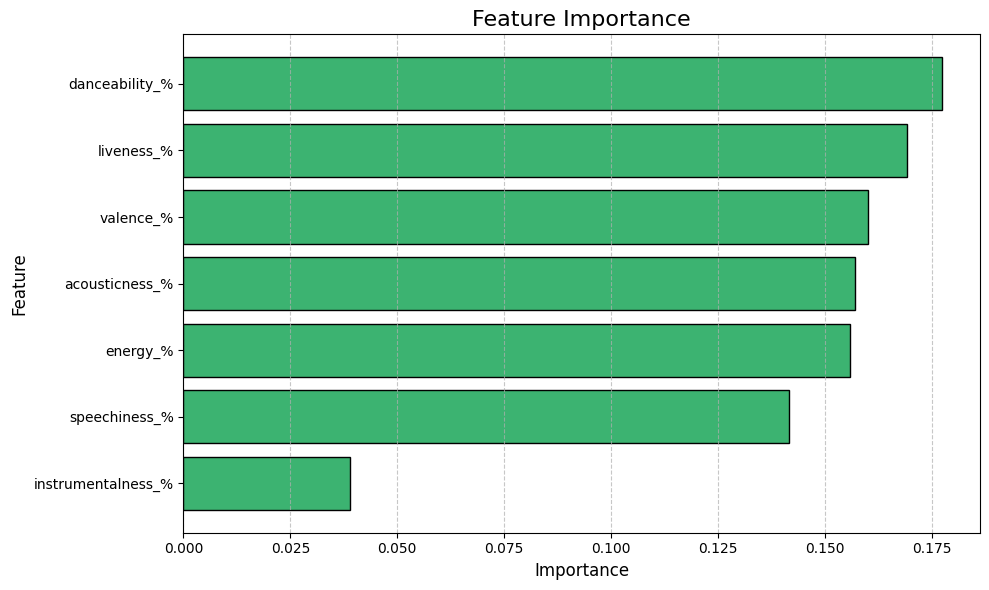

In [ ]:
# Display the table
print("Feature Importance Table:")
print(results)

# Visualize the feature importance as a bar chart
plt.figure(figsize=(10, 6))
plt.barh(results['Feature'], results['Importance'], color='mediumseagreen', edgecolor='black')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
print(classification_report_result)

              precision    recall  f1-score   support

           0       0.58      0.67      0.63        46
           1       0.62      0.52      0.56        46

    accuracy                           0.60        92
   macro avg       0.60      0.60      0.60        92
weighted avg       0.60      0.60      0.60        92



In [ ]:
print(confusion_matrix_result)

[[31 15]
 [22 24]]


###Model 2 - Logistic Regression with Simple Features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Train Logistic Regression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Step 2: Predict on Test Data
y_pred_logistic = logistic_model.predict(X_test)

# Step 3: Evaluate the Model
print("Classification Report:\n", classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))


Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.83      0.68        46
           1       0.70      0.41      0.52        46

    accuracy                           0.62        92
   macro avg       0.64      0.62      0.60        92
weighted avg       0.64      0.62      0.60        92

Confusion Matrix:
 [[38  8]
 [27 19]]


###Model 3 - KNN with Simple Features

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Define the KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)  # Using 5 neighbors as default

# Step 2: Train the KNN Model
knn_model.fit(X_train, y_train)

# Step 3: Predict on Test Data
y_pred_knn = knn_model.predict(X_test)

# Step 4: Evaluate the KNN Model
knn_classification_report = classification_report(y_test, y_pred_knn)
knn_confusion_matrix = confusion_matrix(y_test, y_pred_knn)

# Display the evaluation results
print(knn_classification_report)
print(knn_confusion_matrix)

              precision    recall  f1-score   support

           0       0.60      0.61      0.60        46
           1       0.60      0.59      0.59        46

    accuracy                           0.60        92
   macro avg       0.60      0.60      0.60        92
weighted avg       0.60      0.60      0.60        92

[[28 18]
 [19 27]]


##With All Features

###Split Train and Test Data - All

In [ ]:
# Reloading the dataset with all features
# Exclude the target-related columns and any non-numeric columns
features_all = songs_data.select_dtypes(include=['float64', 'int64']).drop(columns=['top_10_x_times', 'position', 'peak_position', 'total_streams'])

# Define the target variable again
target_all = (songs_data['top_10_x_times'] > 0).astype(int)

# Handle Missing Values
features_all = features_all.fillna(features_all.mean())

# Normalize Features
scaler_all = StandardScaler()
features_all_scaled = scaler_all.fit_transform(features_all)

# Split Data into Training and Testing Sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(features_all_scaled, target_all, test_size=0.2, random_state=42)

print(features_all.columns)

Index(['days', 'peak_streams', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'danceability_%',
       'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%',
       'liveness_%', 'speechiness_%'],
      dtype='object')


###Model 1 - Random Forest Classifier All Features

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model using all features
rf_model_all = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_all.fit(X_train_all, y_train_all)

# Predict on Test Data
y_pred_rf_all = rf_model_all.predict(X_test_all)

# Evaluate the Random Forest Model using all features
rf_all_classification_report = classification_report(y_test_all, y_pred_rf_all)
rf_all_confusion_matrix = confusion_matrix(y_test_all, y_pred_rf_all)

# Feature Importance from Random Forest
rf_all_feature_importance = pd.DataFrame({
    'Feature': features_all.columns,
    'Importance': rf_model_all.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the evaluation metrics
print(rf_all_classification_report)
print(rf_all_confusion_matrix)


              precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       0.91      0.93      0.92        46

    accuracy                           0.92        92
   macro avg       0.92      0.92      0.92        92
weighted avg       0.92      0.92      0.92        92

[[42  4]
 [ 3 43]]


###Model 2 - Logistic Regression All Features

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression using all features
logistic_model_all = LogisticRegression(max_iter=1000)  # Ensure sufficient iterations for convergence
logistic_model_all.fit(X_train_all, y_train_all)

# Predict on Test Data
y_pred_logistic_all = logistic_model_all.predict(X_test_all)

# Evaluate the Logistic Regression Model using all features
logistic_all_classification_report = classification_report(y_test_all, y_pred_logistic_all)
logistic_all_confusion_matrix = confusion_matrix(y_test_all, y_pred_logistic_all)

# Coefficients from Logistic Regression
logistic_all_feature_importance = pd.DataFrame({
    'Feature': features_all.columns,
    'Coefficient': logistic_model_all.coef_[0]
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute value of coefficients

# Display evaluation metrics
print(logistic_all_classification_report)
print(logistic_all_confusion_matrix)


              precision    recall  f1-score   support

           0       0.84      0.89      0.86        46
           1       0.88      0.83      0.85        46

    accuracy                           0.86        92
   macro avg       0.86      0.86      0.86        92
weighted avg       0.86      0.86      0.86        92

[[41  5]
 [ 8 38]]


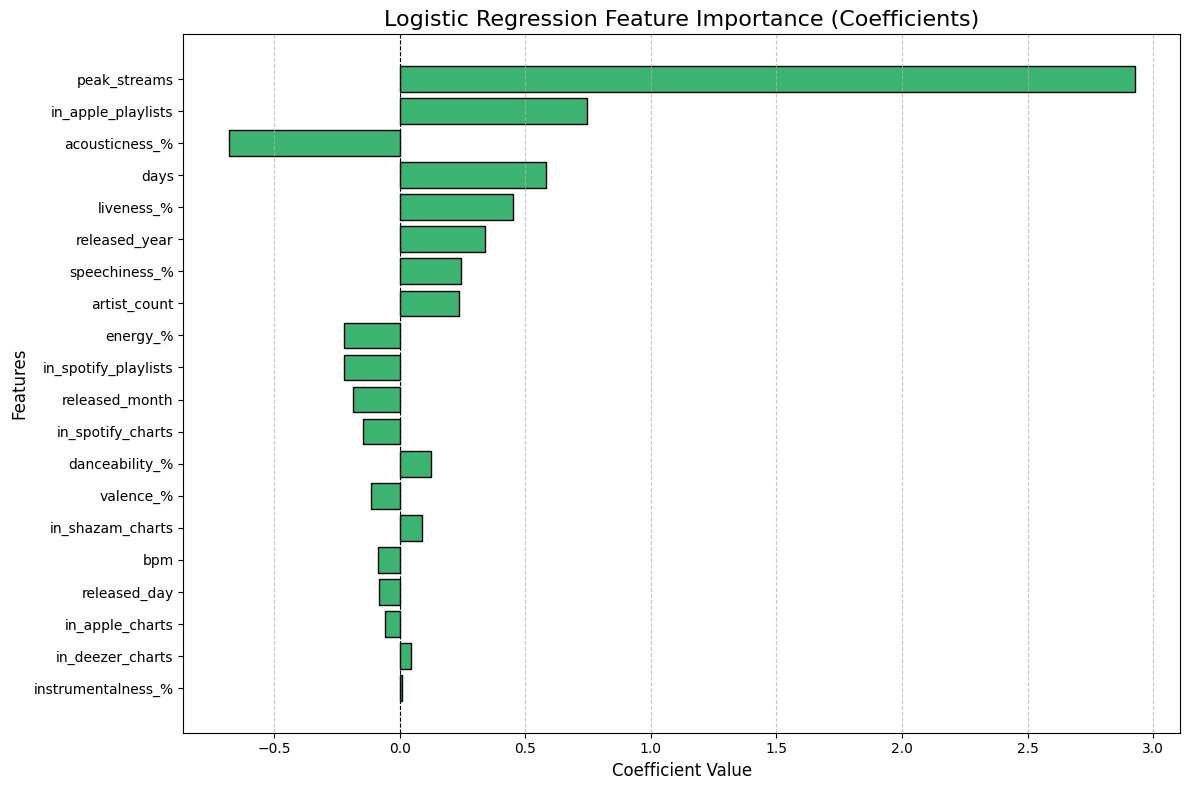

In [ ]:
# Visualizing the logistic regression coefficients (feature importance)
plt.figure(figsize=(12, 8))
plt.barh(logistic_all_feature_importance['Feature'], logistic_all_feature_importance['Coefficient'], color='mediumseagreen', edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # Reference line at 0
plt.title("Logistic Regression Feature Importance (Coefficients)", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest importance on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


###Model 3 - KNN All Features

In [ ]:
# Train the KNN Model using all features
knn_model_all = KNeighborsClassifier(n_neighbors=5)
knn_model_all.fit(X_train_all, y_train_all)

# Predict on Test Data
y_pred_knn_all = knn_model_all.predict(X_test_all)

# Evaluate the KNN Model using all features
knn_all_classification_report = classification_report(y_test_all, y_pred_knn_all)
knn_all_confusion_matrix = confusion_matrix(y_test_all, y_pred_knn_all)

# Display the results
print(knn_all_classification_report)
print(knn_all_confusion_matrix)


              precision    recall  f1-score   support

           0       0.73      0.87      0.79        46
           1       0.84      0.67      0.75        46

    accuracy                           0.77        92
   macro avg       0.78      0.77      0.77        92
weighted avg       0.78      0.77      0.77        92

[[40  6]
 [15 31]]


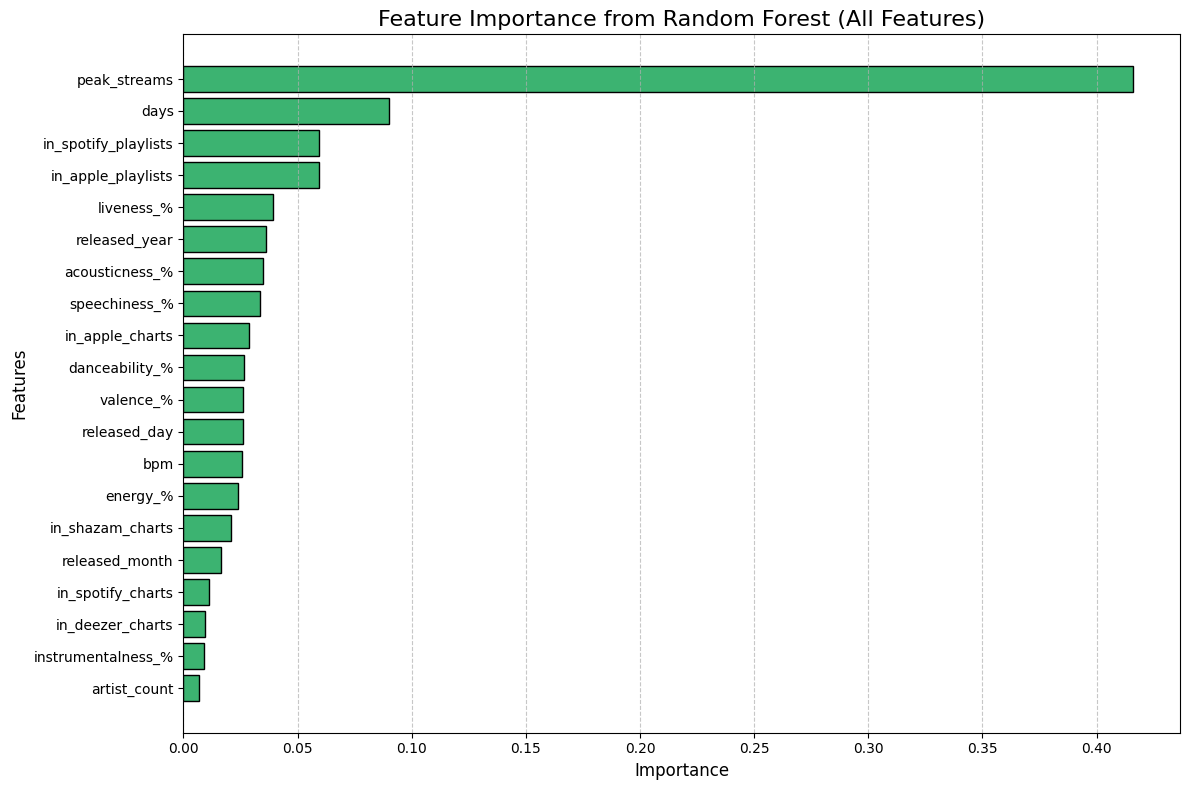

In [ ]:
# Visualizing the feature importance from the Random Forest model
plt.figure(figsize=(12, 8))
plt.barh(rf_all_feature_importance['Feature'], rf_all_feature_importance['Importance'], color='mediumseagreen', edgecolor='black')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Feature Importance from Random Forest (All Features)", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##With Selected Features

###Split and Train Test Data - Selected

In [ ]:
# Select the specified features for the Random Forest model
selected_features = [
    'artist_count', 'released_month', 'released_day', 'bpm',
    'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
    'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

# Filter the dataset to include only these features
X_selected = songs_data[selected_features]
y_selected = (songs_data['top_10_x_times'] > 0).astype(int)  # Define the target variable

# Handle Missing Values
X_selected = X_selected.fillna(X_selected.mean())

# Normalize Features
scaler_selected = StandardScaler()
X_selected_scaled = scaler_selected.fit_transform(X_selected)

# Split Data into Training and Testing Sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_scaled, y_selected, test_size=0.2, random_state=42
)


###Model 1 - Random Forest with Selected Features

In [ ]:
from sklearn.metrics import accuracy_score

# Train Random Forest Model using selected features
rf_model_selected = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_selected.fit(X_train_selected, y_train_selected)

# Predict on Test Data
y_pred_rf_selected = rf_model_selected.predict(X_test_selected)

# Evaluate the Random Forest Model using selected features
rf_selected_classification_report = classification_report(y_test_selected, y_pred_rf_selected)
rf_selected_confusion_matrix = confusion_matrix(y_test_selected, y_pred_rf_selected)

# Feature Importance for Selected Features
rf_selected_feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model_selected.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the evaluation metrics
print(rf_selected_classification_report)
print(rf_selected_confusion_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test_selected, y_pred_rf_selected)
print(f"Accuracy: {accuracy:.2f}")


              precision    recall  f1-score   support

           0       0.60      0.70      0.65        46
           1       0.64      0.54      0.59        46

    accuracy                           0.62        92
   macro avg       0.62      0.62      0.62        92
weighted avg       0.62      0.62      0.62        92

[[32 14]
 [21 25]]
Accuracy: 0.62


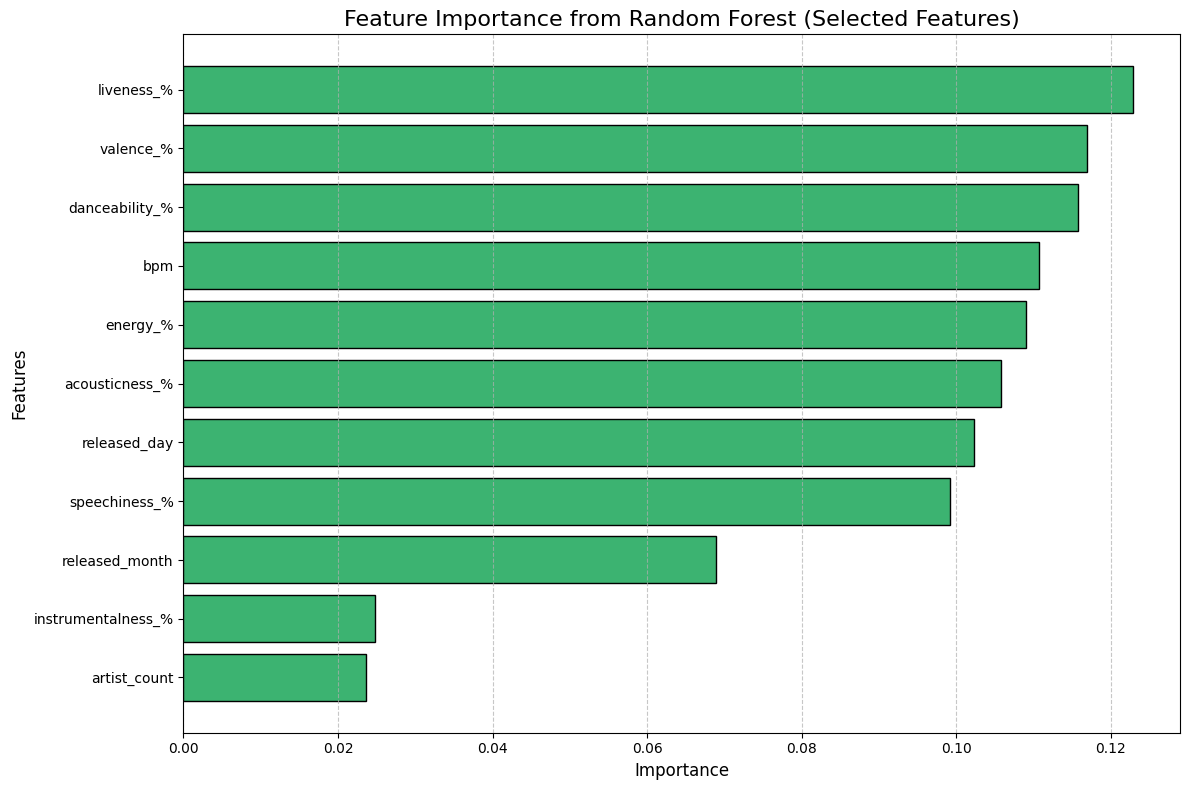

In [ ]:
# Visualizing the feature importance from the Random Forest model with selected features
plt.figure(figsize=(12, 8))
plt.barh(rf_selected_feature_importance['Feature'], rf_selected_feature_importance['Importance'], color='mediumseagreen', edgecolor='black')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Feature Importance from Random Forest (Selected Features)", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


####Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define a simplified parameter grid
param_grid = {
    'n_estimators': [100, 150, 300],
    'max_depth': [10, 20, 50],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  # Number of folds for cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the model on the selected features
grid_search.fit(X_train_selected, y_train_selected)

# Best hyperparameters
best_params = grid_search.best_params_

# Train the model with the best parameters
best_rf_model = grid_search.best_estimator_

# Predict on test data
y_pred_best_rf = best_rf_model.predict(X_test_selected)

# Evaluate the model
classification_report_best_rf = classification_report(y_test_selected, y_pred_best_rf)
confusion_matrix_best_rf = confusion_matrix(y_test_selected, y_pred_best_rf)
accuracy_best_rf = accuracy_score(y_test_selected, y_pred_best_rf)

print("Best Parameters:", best_params)
print("Classification Report:\n", classification_report_best_rf)
print("Confusion Matrix:\n", confusion_matrix_best_rf)
print(f"Accuracy: {accuracy_best_rf:.2f}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.74      0.66        46
           1       0.66      0.50      0.57        46

    accuracy                           0.62        92
   macro avg       0.63      0.62      0.61        92
weighted avg       0.63      0.62      0.61        92

Confusion Matrix:
 [[34 12]
 [23 23]]
Accuracy: 0.62


###Model 2 - Logistic Regression With Selected Features

In [ ]:
from sklearn.metrics import accuracy_score

# Train Logistic Regression using the selected features
logistic_model_selected = LogisticRegression(max_iter=1000)  # Ensure sufficient iterations for convergence
logistic_model_selected.fit(X_train_selected, y_train_selected)

# Predict on Test Data
y_pred_logistic_selected = logistic_model_selected.predict(X_test_selected)

# Evaluate the Logistic Regression Model using selected features
logistic_selected_classification_report = classification_report(y_test_selected, y_pred_logistic_selected)
logistic_selected_confusion_matrix = confusion_matrix(y_test_selected, y_pred_logistic_selected)

# Coefficients from Logistic Regression
logistic_selected_feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': logistic_model_selected.coef_[0]
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute value of coefficients

# Display evaluation metrics
print(logistic_selected_classification_report)
print(logistic_selected_confusion_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test_selected, y_pred_logistic_selected)
print(f"Accuracy: {accuracy:.2f}")


              precision    recall  f1-score   support

           0       0.59      0.78      0.67        46
           1       0.68      0.46      0.55        46

    accuracy                           0.62        92
   macro avg       0.63      0.62      0.61        92
weighted avg       0.63      0.62      0.61        92

[[36 10]
 [25 21]]
Accuracy: 0.62


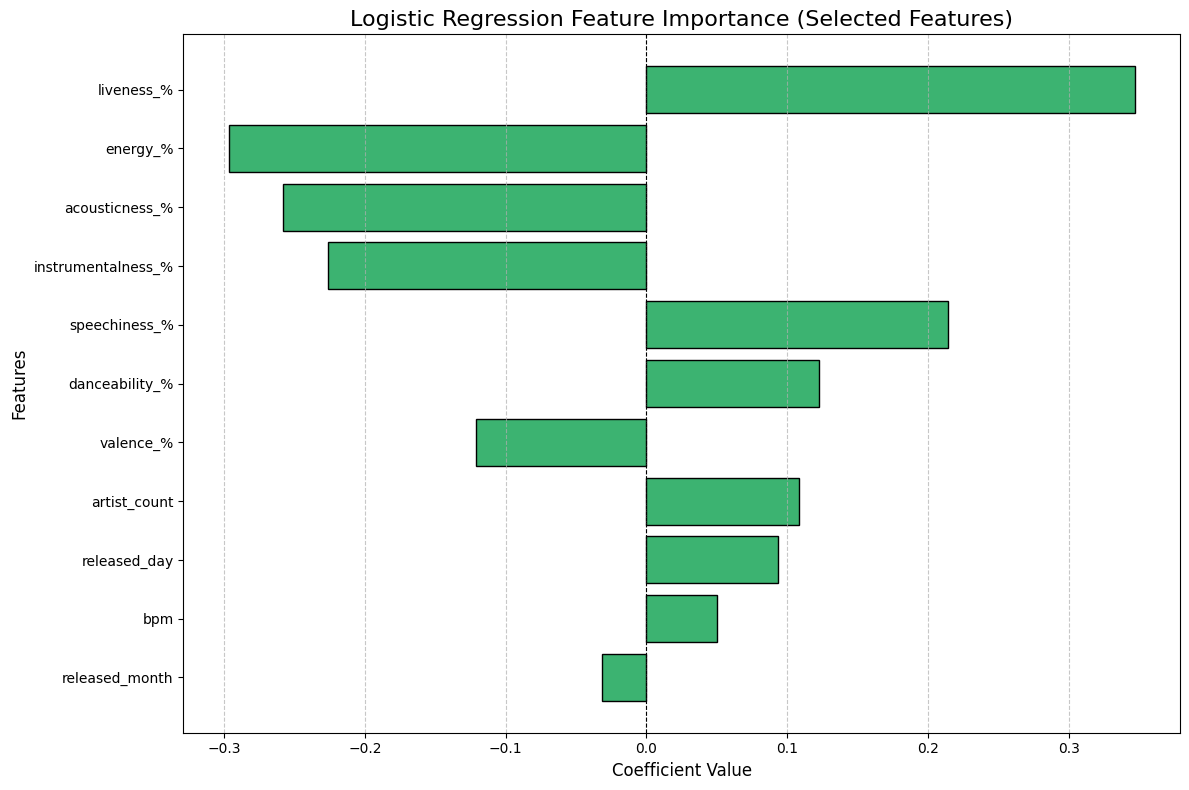

In [ ]:
# Visualizing the logistic regression coefficients (feature importance) for selected features
plt.figure(figsize=(12, 8))
plt.barh(logistic_selected_feature_importance['Feature'], logistic_selected_feature_importance['Coefficient'], color='mediumseagreen', edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # Reference line at 0
plt.title("Logistic Regression Feature Importance (Selected Features)", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest importance on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Results

##Final Model Selection

**With Selected Features: Model 1 - Random Forest with Selected Features**



Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.70      0.65        46
           1       0.64      0.54      0.59        46

    accuracy                           0.62        92
   macro avg       0.62      0.62      0.62        92
weighted avg       0.62      0.62      0.62        92

Confusion Matrix:

[[32 14]
 [21 25]]

##Final Model Explanation


This model demonstrates solid performance based on the provided metrics, making it a good choice:


Both precision (0.60-0.64) and recall (0.54-0.70) are reasonably high, indicating that the model performs well in making correct predictions while minimizing false positives and false negatives.


The F1-scores (0.59-0.65) suggest a good balance between precision and recall, making the model effective for predictions where both accuracy in identifying correct cases and minimizing errors are important.

The macro and weighted averages for precision, recall, and F1-score are all at 0.62, showing consistent performance across the dataset without any significant weaknesses.

An accuracy of 62% demonstrates that the model is performing significantly better than random guessing for a binary classification problem, providing meaningful predictions.

This model exhibits reliable and balanced performance across all key metrics. With precision and recall ranging from 0.54 to 0.70, it effectively minimizes errors while making accurate predictions. The F1-scores (0.59-0.65) highlight a solid balance between precision and recall, reinforcing its suitability for tasks where both metrics are important. Additionally, macro and weighted averages of 0.62 indicate consistent performance across the dataset, without significant weaknesses. An overall accuracy of 62% further confirms the model's ability to provide meaningful predictions, surpassing the baseline for binary classification.

We selected Random Forest with chosen features over Logistic Regression due to the following capabilities of Random Forest:

* Non-Linear or Complex Relationships: Random Forest is a non-linear model and handles complex feature interactions well. Suitable when the relationship between features and the target is not linear.

* High-Dimensional Data

* Can handle large numbers of features effectively without requiring extensive preprocessing (e.g., scaling or one-hot encoding).
Robustness to Noise and Missing Data

* Handles noisy data better and can tolerate missing values by using split criteria on available data.
Feature Importance Analysis

* Random Forest provides insights into feature importance, useful for identifying key drivers in predictions.
Preventing Overfitting

* Uses ensemble learning (multiple decision trees) to reduce overfitting risk while capturing more complex patterns.
Larger Datasets

* Performs better with larger datasets compared to Logistic Regression.
Multi-class or Imbalanced Data

* Handles multi-class classification and imbalanced datasets more effectively than Logistic Regression.





### Sample Predictions for Top 10

In [ ]:
# Create sample data for Top 10 prediction
sample_data = pd.DataFrame({
    'artist_count': [3, 5, 2],
    'released_month': [6, 11, 3],
    'released_day': [15, 22, 7],
    'bpm': [120, 95, 140],
    'danceability_%': [80, 50, 70],
    'valence_%': [60, 40, 50],
    'energy_%': [70, 60, 80],
    'acousticness_%': [20, 30, 10],
    'instrumentalness_%': [0.0, 0.1, 0.05],
    'liveness_%': [10, 15, 5],
    'speechiness_%': [8, 7, 9]
})

# Normalize the sample data using the previously fitted scaler
sample_data_scaled = scaler_selected.transform(sample_data)

# Predict using the trained Random Forest model
sample_predictions = rf_model_selected.predict(sample_data_scaled)

# Display the sample predictions
sample_data['Predicted_Top_10'] = sample_predictions

print(sample_data)


   artist_count  released_month  released_day  bpm  danceability_%  valence_%  \
0             3               6            15  120              80         60   
1             5              11            22   95              50         40   
2             2               3             7  140              70         50   

   energy_%  acousticness_%  instrumentalness_%  liveness_%  speechiness_%  \
0        70              20                0.00          10              8   
1        60              30                0.10          15              7   
2        80              10                0.05           5              9   

   Predicted_Top_10  
0                 1  
1                 1  
2                 1  


### Sample Predictions for NOT Top 10 (Extreme Examples)

In [ ]:
# Generate up to 10 more examples unlikely to be in the top 10
expanded_non_top_10_sample_data = pd.DataFrame({
    'artist_count': [50, 45, 55, 60, 70, 65, 80, 75, 85, 90],
    'released_month': [10, 11, 1, 2, 3, 4, 5, 6, 7, 8],
    'released_day': [12, 8, 20, 15, 10, 5, 30, 25, 18, 1],
    'bpm': [35, 40, 42, 38, 37, 39, 45, 43, 41, 36],
    'danceability_%': [10, 5, 8, 12, 7, 9, 11, 6, 4, 3],
    'valence_%': [2, 3, 4, 1, 5, 2, 3, 1, 4, 5],
    'energy_%': [6, 5, 7, 4, 6, 5, 8, 7, 6, 5],
    'acousticness_%': [96, 97, 98, 99, 95, 96, 97, 98, 99, 95],
    'instrumentalness_%': [0.99, 0.98, 1.0, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91],
    'liveness_%': [85, 80, 82, 83, 87, 88, 84, 81, 86, 89],
    'speechiness_%': [48, 49, 50, 51, 52, 53, 54, 55, 56, 57]
})

# Normalize the new sample data
expanded_non_top_10_sample_scaled = scaler_selected.transform(expanded_non_top_10_sample_data)

# Predict using the trained Random Forest model
expanded_non_top_10_predictions = rf_model_selected.predict(expanded_non_top_10_sample_scaled)

# Include only those predicted as not in the top 10
expanded_non_top_10_sample_data['Predicted_Top_10'] = expanded_non_top_10_predictions
not_top_10_songs = expanded_non_top_10_sample_data[expanded_non_top_10_sample_data['Predicted_Top_10'] == 0]

# Limit to 10 examples and display
not_top_10_songs = not_top_10_songs.head(10)

print(not_top_10_songs)


   artist_count  released_month  released_day  bpm  danceability_%  valence_%  \
0            50              10            12   35              10          2   
3            60               2            15   38              12          1   
4            70               3            10   37               7          5   
5            65               4             5   39               9          2   
6            80               5            30   45              11          3   

   energy_%  acousticness_%  instrumentalness_%  liveness_%  speechiness_%  \
0         6              96                0.99          85             48   
3         4              99                0.97          83             51   
4         6              95                0.96          87             52   
5         5              96                0.95          88             53   
6         8              97                0.94          84             54   

   Predicted_Top_10  
0                 0  


##Discussion

As promised we discuss here potential plans to project our work in this small-scope experiment to bigger issues in discussion section.

**Power** of the Model

For Label Companies
Our model provides a data-driven tool to predict the commercial potential of songs, enabling record labels to make more informed decisions on marketing strategies, budgeting, and resource allocation. By identifying patterns that contribute to success, the model could serve as a guide for selecting singles from an album or prioritizing songs for promotional campaigns, thus reducing financial risks associated with high-stakes releases.

For Artists
For artists, the model offers valuable insights into factors influencing song popularity, allowing them to make data-informed creative decisions without compromising artistic integrity. By understanding trends in listener preferences, artists could tailor their music to resonate with audiences, balancing originality with commercial appeal. Additionally, independent artists could leverage these insights to gain a competitive edge in a crowded music industry.

**Limitations** of the Model

Despite its utility, our model has several limitations. First, the data sources used in this experiment may not capture all variables influencing music success, such as cultural trends, external events, or unforeseen viral phenomena. Additionally, the model’s reliance on historical data could limit its adaptability to shifting musical tastes over time. Finally, there is potential for bias in the training data, which might skew predictions and inadvertently marginalize certain genres or demographics.

Extending to **Further Unsupervised Learning**

One avenue for improving the model is through unsupervised learning techniques, which could uncover latent features or hidden structures in the data. By clustering songs based on nuanced audio characteristics or consumer behaviors, we could enhance the model’s predictive power and generalizability. For example, unsupervised learning could identify emerging subgenres or trends that are not yet mainstream but have the potential for high success.

**Frontiers**: Exploring Other Variables or New Ways of Interpretations of Music entirely

Looking forward, an exciting frontier is the incorporation of additional variables, such as social media engagement metrics, playlist inclusion rates, and even visual elements like album art. Moreover, rethinking how we interpret music—through sentiment analysis of lyrics, emotional content of melodies, or even physiological responses in listeners—could open new dimensions for prediction. Another potential direction is leveraging generative AI to simulate potential song variations and predict their respective success outcomes, offering a proactive tool for both labels and artists.


